In [31]:
import numpy as np
import tqdm
import os
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import yt
yt.set_log_level("error")

In [32]:
run_dir = '../run'

# 2D SlicePlot of the blast

In [33]:
ds.field_list

[('boxlib', 'Gamma_1'),
 ('boxlib', 'MachNumber'),
 ('boxlib', 'StateErr_0'),
 ('boxlib', 'StateErr_1'),
 ('boxlib', 'StateErr_2'),
 ('boxlib', 'Temp'),
 ('boxlib', 'X(Hn)'),
 ('boxlib', 'X(Hp)'),
 ('boxlib', 'abar'),
 ('boxlib', 'angular_momentum_x'),
 ('boxlib', 'angular_momentum_y'),
 ('boxlib', 'angular_momentum_z'),
 ('boxlib', 'circvel'),
 ('boxlib', 'density'),
 ('boxlib', 'divu'),
 ('boxlib', 'eint_E'),
 ('boxlib', 'eint_e'),
 ('boxlib', 'entropy'),
 ('boxlib', 'kineng'),
 ('boxlib', 'logden'),
 ('boxlib', 'magmom'),
 ('boxlib', 'magvel'),
 ('boxlib', 'magvort'),
 ('boxlib', 'pressure'),
 ('boxlib', 'radvel'),
 ('boxlib', 'rho_E'),
 ('boxlib', 'rho_Hn'),
 ('boxlib', 'rho_Hp'),
 ('boxlib', 'rho_e'),
 ('boxlib', 'soundspeed'),
 ('boxlib', 'x_velocity'),
 ('boxlib', 'xmom'),
 ('boxlib', 'y_velocity'),
 ('boxlib', 'ymom'),
 ('boxlib', 'z_velocity'),
 ('boxlib', 'zmom')]


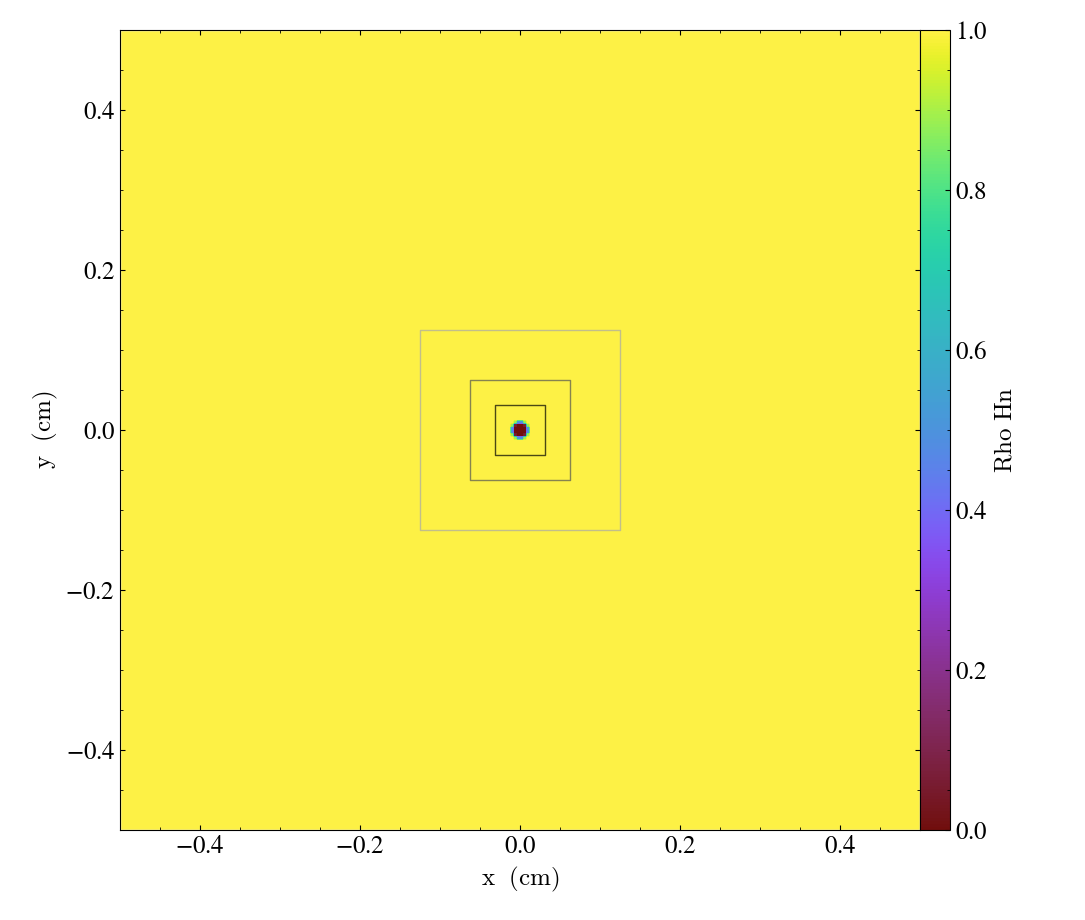

In [42]:
ds = yt.load('../run/plt00000/', hint="castro")
quantity = 'rho_Hn'
sl = yt.SlicePlot(ds, 'z', quantity)
sl.set_log(quantity, False)
sl.annotate_grids()


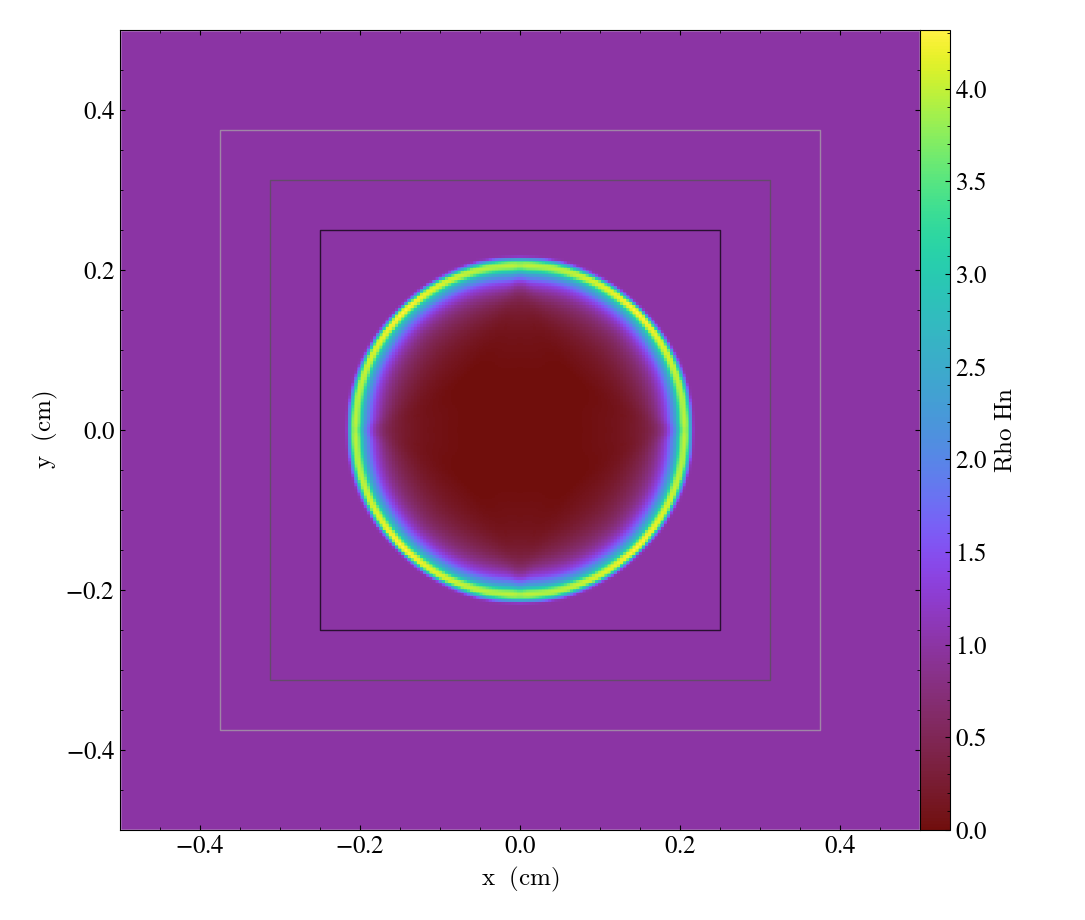

In [35]:
ds = yt.load('../run/plt00100/', hint="castro")
quantity = 'rho_Hn'
sl = yt.SlicePlot(ds, 'z', quantity)
sl.set_log(quantity, False)
sl.annotate_grids()

# Extract data

In [36]:
def extract_data( iteration, quantity, level ):
    ds = yt.load('../run/plt%05d/' %iteration, hint="castro")
    ad = ds.covering_grid( level=level, 
                           left_edge=ds.domain_left_edge, 
                           dims=[ds.domain_dimensions[0]*2**level, ds.domain_dimensions[1]*2**level, 1] )
    q = ad[quantity].to_ndarray().squeeze()
    q = q[q.shape[0]//2:,q.shape[1]//2]
    r = np.linspace(
        0.5*(ds.domain_left_edge[0] + ds.domain_right_edge[0]),
        ds.domain_right_edge[0],
        ds.domain_dimensions[0]*2**level//2)
    r -= 0.5*(ds.domain_left_edge[0] + ds.domain_right_edge[0])
    return r, q, ds.current_time

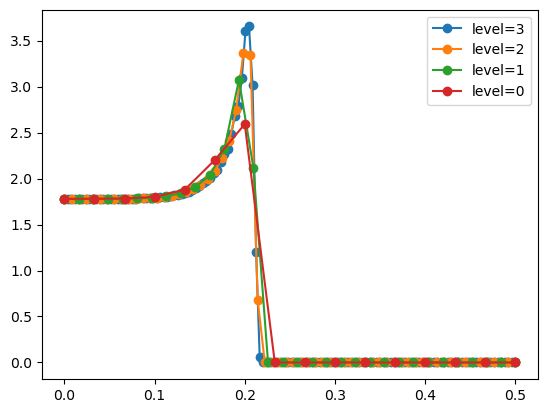

In [37]:
# plot data at difference resolutions
plt.clf()
for level in range(3,-1,-1):
    r, q, t = extract_data( 100, 'pressure', level)
    plt.plot(r, q, '-o', label='level=%d'%level)
plt.legend(loc=0)

In [38]:
# Extract data from different time 
# Note that time is not regularly spaced
t_arr = []
q_arr = []
rmax_arr = []
iterations = sorted([ int(filename[3:]) 
                     for filename in os.listdir(run_dir) 
                     if filename.startswith('plt') ])
for iteration in tqdm.tqdm(iterations):
    r, q, t = extract_data(iteration, 'density', level=2)
    rmax = r[np.argmax(q)]
    t_arr.append(t)
    rmax_arr.append(rmax)
    q_arr.append(q)
q_arr = np.stack(q_arr)
t_arr = np.array(t_arr)
r_arr = r.to_ndarray()

# Interpolate on a grid with regularly-spaced time
interp = RegularGridInterpolator(points=(t_arr, r_arr), values=q_arr, bounds_error=False, fill_value=None)
t_interp, r_interp = np.meshgrid(
    np.linspace(0, t_arr.max(), 1000), 
    np.linspace(0, r_arr.max(), 1000), indexing='ij')
q_interp = interp((t_interp, r_interp))

100%|███████████████████████████████████████████| 33/33 [00:07<00:00,  4.64it/s]


In [39]:
# Calculate analytical solution
gamma = 1.4
rho = 1. # g / cm^3
E = 1. # erg / cm
r_analytical = np.sqrt( gamma+1 ) * (E/np.pi/rho)**(1./4) * np.sqrt(t_arr)

Text(0.5, 0, 't (s)')

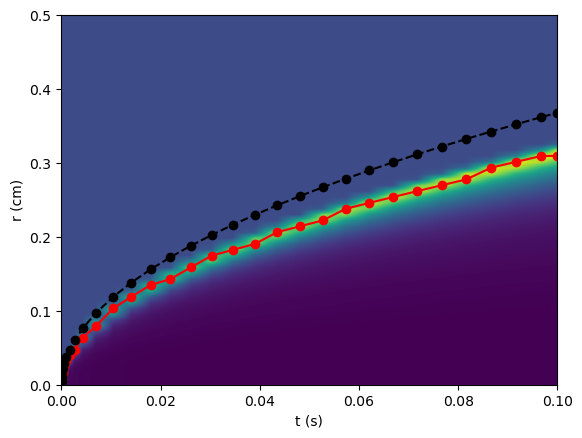

In [40]:
plt.imshow(q_interp.T, origin='lower', extent=[0, t_arr.max(), 0, r_arr.max()], aspect='auto')
plt.plot(t_arr, rmax_arr, 'r-o')
plt.plot(t_arr, r_analytical, 'k--o')
plt.ylabel('r (cm)')
plt.xlabel('t (s)')